#Business Problem Statement

The objective of this project is to develop a machine learning model that determines optimal retail product pricing to maximize profitability while maintaining competitive positioning in the market.

The model will utilize historical sales data, competitor pricing, seasonal trends, and product attributes to predict optimal price points (Target: Lag_Price).

By implementing this pricing optimization system, the company aims to:

• Increase profit margins

• Improve competitive pricing strategies

• Enable data-driven decision-making

• Enhance overall business performance

Importing Required Libraries

This section imports all necessary Python libraries for data manipulation, visualization, modeling, and evaluation.

In [5]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model Explainability
import shap
from sklearn.inspection import permutation_importance

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

##Data Loading

In this section, we load the dataset and inspect its structure, shape, and basic information to understand the data types and identify potential issues such as missing values.

In [6]:
# Load Dataset
df = pd.read_csv('retail_price.csv')

# Display first 5 rows
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [7]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Data types and non-null values
df.info()

# Summary statistics
df.describe()

Dataset Shape: (676, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday   

,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,...,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,14.495562,1422.708728,20.682270,106.496800,48.720414,767.399408,1.994083,1847.498521,4.085503,81.028107,...,79.452054,4.159467,18.597610,92.930079,4.123521,18.620644,84.182642,4.002071,17.965007,107.399684
std,15.443421,1700.123100,10.081817,76.182972,9.420715,655.205015,1.420473,2274.808483,0.232021,62.055560,...,47.933358,0.121652,9.406537,49.481269,0.207189,6.424174,47.745789,0.233292,5.533256,76.974657
min,1.000000,19.900000,0.000000,19.900000,29.000000,100.000000,1.000000,100.000000,3.300000,1.000000,...,19.900000,3.700000,0.095439,19.900000,3.300000,4.410000,19.900000,3.500000,7.670000,19.850000
25%,4.000000,333.700000,14.761912,53.900000,40.000000,339.000000,1.000000,348.000000,3.900000,34.000000,...,49.910000,4.100000,13.826429,53.900000,4.100000,14.485000,53.785714,3.900000,15.042727,55.668750
50%,10.000000,807.890000,17.518472,89.900000,51.000000,501.000000,1.500000,950.000000,4.100000,62.000000,...,69.900000,4.200000,16.618984,89.990000,4.200000,16.811765,59.900000,4.000000,16.517110,89.900000
75%,18.000000,1887.322500,22.713558,129.990000,57.000000,903.000000,2.000000,1850.000000,4.200000,116.000000,...,104.256549,4.200000,19.732500,117.888889,4.200000,21.665238,99.990000,4.100000,19.447778,129.990000
max,122.000000,12095.000000,79.760000,364.000000,60.000000,3006.000000,8.000000,9750.000000,4.500000,339.000000,...,349.900000,4.500000,57.230000,349.900000,4.400000,57.230000,255.610000,4.400000,57.230000,364.000000


#Initial Observations

- The dataset contains 676 rows and 30 columns.
- There are no missing values across all columns.
- Data types are correctly assigned (numerical and categorical separated properly).
- The dataset includes product details, pricing, competitor information, and time-based features.
- The target variable is `lag_price`.

Key Considerations:
- The dataset size is relatively small (676 records), so overfitting risk must be handled carefully.
- Since this is time-based data (month_year), temporal ordering must be considered before splitting data.

##Data Validation & Cleaning

In this section, we validate relationships between features and check for redundant or highly correlated variables that may impact model performance.

In [8]:
# Check if total_price ≈ unit_price * qty
df['calculated_total'] = df['unit_price'] * df['qty']

# Compare difference
df['price_difference'] = df['total_price'] - df['calculated_total']

df[['total_price', 'calculated_total', 'price_difference']].head()

,total_price,calculated_total,price_difference
0,45.95,45.95,0.000000e+00
1,137.85,137.85,-2.842171e-14
2,275.70,275.70,-5.684342e-14
3,183.80,183.80,0.000000e+00
4,91.90,91.90,0.000000e+00


In [9]:
# Convert month_year to datetime
df['month_year'] = pd.to_datetime(df['month_year'], format='%d-%m-%Y')

# Sort by product and date
df = df.sort_values(by=['product_id', 'month_year'])

df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,calculated_total,price_difference
0,bed1,bed_bath_table,2017-05-01,1,45.95,15.100000,45.95,39,161,2,...,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,45.95,0.000000e+00
1,bed1,bed_bath_table,2017-06-01,3,137.85,12.933333,45.95,39,161,2,...,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,137.85,-2.842171e-14
2,bed1,bed_bath_table,2017-07-01,6,275.70,14.840000,45.95,39,161,2,...,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,275.70,-5.684342e-14
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.95,39,161,2,...,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,183.80,0.000000e+00
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.95,39,161,2,...,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,91.90,0.000000e+00


##Removing Redundant Features

The column `total_price` is mathematically derived from `unit_price × qty`.
Since it does not provide additional information, it is removed to prevent redundancy and multicollinearity issues in the model.

In [10]:
# Drop redundant columns
df.drop(['total_price', 'calculated_total', 'price_difference'], axis=1, inplace=True)

df.head()

,product_id,product_category_name,month_year,qty,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,2017-05-01,1,15.100000,45.95,39,161,2,350,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,2017-06-01,3,12.933333,45.95,39,161,2,350,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,2017-07-01,6,14.840000,45.95,39,161,2,350,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,2017-08-01,4,14.287500,45.95,39,161,2,350,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,2017-09-01,2,15.100000,45.95,39,161,2,350,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [11]:
# Check if lag_price equals previous month's unit_price per product
df['prev_unit_price'] = df.groupby('product_id')['unit_price'].shift(1)

df[['product_id', 'month_year', 'unit_price', 'lag_price', 'prev_unit_price']].head(10)

,product_id,month_year,unit_price,lag_price,prev_unit_price
0,bed1,2017-05-01,45.950000,45.900000,NaN
1,bed1,2017-06-01,45.950000,45.950000,45.950000
2,bed1,2017-07-01,45.950000,45.950000,45.950000
3,bed1,2017-08-01,45.950000,45.950000,45.950000
4,bed1,2017-09-01,45.950000,45.950000,45.950000
5,bed1,2017-10-01,45.950000,45.950000,45.950000
6,bed1,2017-11-01,40.531818,45.950000,45.950000
7,bed1,2017-12-01,39.990000,40.531818,40.531818
8,bed1,2018-01-01,39.990000,39.990000,39.990000
9,bed1,2018-02-01,39.990000,39.990000,39.990000


##Feature Engineering

In this section, we create additional features that capture competitive positioning and pricing differences.
These engineered features help the model understand how our pricing compares to competitors.

In [12]:
# Price difference vs competitors
df['diff_comp1'] = df['unit_price'] - df['comp_1']
df['diff_comp2'] = df['unit_price'] - df['comp_2']
df['diff_comp3'] = df['unit_price'] - df['comp_3']

# Average competitor price
df['avg_comp_price'] = (df['comp_1'] + df['comp_2'] + df['comp_3']) / 3

# Relative price index
df['price_index'] = df['unit_price'] / df['avg_comp_price']

df.head()

,product_id,product_category_name,month_year,qty,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,...,comp_3,ps3,fp3,lag_price,prev_unit_price,diff_comp1,diff_comp2,diff_comp3,avg_comp_price,price_index
0,bed1,bed_bath_table,2017-05-01,1,15.100000,45.95,39,161,2,350,...,45.95,4.0,15.100000,45.90,NaN,-43.95,-169.050000,0.0,116.950000,0.392903
1,bed1,bed_bath_table,2017-06-01,3,12.933333,45.95,39,161,2,350,...,45.95,4.0,12.933333,45.95,45.95,-43.95,-163.050000,0.0,114.950000,0.399739
2,bed1,bed_bath_table,2017-07-01,6,14.840000,45.95,39,161,2,350,...,45.95,4.0,14.840000,45.95,45.95,-43.95,-159.050000,0.0,113.616667,0.404430
3,bed1,bed_bath_table,2017-08-01,4,14.287500,45.95,39,161,2,350,...,45.95,4.0,14.287500,45.95,45.95,-43.95,-153.559804,0.0,111.786601,0.411051
4,bed1,bed_bath_table,2017-09-01,2,15.100000,45.95,39,161,2,350,...,45.95,4.0,15.100000,45.95,45.95,-43.95,-117.448710,0.0,99.749570,0.460654


##Removing Data Leakage & Irrelevant Features

To prevent data leakage and ensure model integrity, columns that directly reveal the target or serve as identifiers are removed before training.

In [13]:
# Drop leakage and unnecessary columns
df_model = df.drop([
    'product_id',
    'month_year',
    'prev_unit_price'
], axis=1)

df_model.head()

,product_category_name,qty,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,fp2,comp_3,ps3,fp3,lag_price,diff_comp1,diff_comp2,diff_comp3,avg_comp_price,price_index
0,bed_bath_table,1,15.100000,45.95,39,161,2,350,4.0,57,...,8.760000,45.95,4.0,15.100000,45.90,-43.95,-169.050000,0.0,116.950000,0.392903
1,bed_bath_table,3,12.933333,45.95,39,161,2,350,4.0,61,...,21.322000,45.95,4.0,12.933333,45.95,-43.95,-163.050000,0.0,114.950000,0.399739
2,bed_bath_table,6,14.840000,45.95,39,161,2,350,4.0,123,...,22.195932,45.95,4.0,14.840000,45.95,-43.95,-159.050000,0.0,113.616667,0.404430
3,bed_bath_table,4,14.287500,45.95,39,161,2,350,4.0,90,...,19.412885,45.95,4.0,14.287500,45.95,-43.95,-153.559804,0.0,111.786601,0.411051
4,bed_bath_table,2,15.100000,45.95,39,161,2,350,4.0,54,...,24.324687,45.95,4.0,15.100000,45.95,-43.95,-117.448710,0.0,99.749570,0.460654


In [14]:
# Define target
y = df_model['lag_price']

# Define features
X = df_model.drop('lag_price', axis=1)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (676, 31)
Target Shape: (676,)


In [15]:
# Time-based split
train = df_model[df['year'] < 2018]
test = df_model[df['year'] >= 2018]

X_train = train.drop('lag_price', axis=1)
y_train = train['lag_price']

X_test = test.drop('lag_price', axis=1)
y_test = test['lag_price']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (321, 31)
Test size: (355, 31)


##Data Preprocessing

We apply proper preprocessing using a ColumnTransformer:
- One-hot encoding for categorical variables
- Standard scaling for numerical features

This ensures the model receives properly formatted inputs.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_cols = ['product_category_name']
numerical_cols = X_train.columns.drop('product_category_name')

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

##Ridge Regression Model

Ridge Regression is used to handle potential multicollinearity among features.
It applies L2 regularization to prevent overfitting.

In [17]:
from sklearn.linear_model import Ridge

# Create pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# Train model
ridge_pipeline.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_pipeline.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge R2 Score:", r2_ridge)
print("Ridge MAE:", mae_ridge)

Ridge R2 Score: 0.9868024041095355
Ridge MAE: 4.922360681976995


##Ridge Regression Results

- R² Score: 0.9868
- Mean Absolute Error: 4.92

The model demonstrates strong predictive performance, explaining approximately 98.68% of the variance in lag_price.

However, this high performance is largely influenced by price persistence over time, where product prices tend to remain relatively stable across months.

This indicates that the model is effectively capturing temporal price continuity rather than complex nonlinear relationships.

##Random Forest Regression Model

Random Forest is an ensemble-based model capable of capturing nonlinear relationships and complex feature interactions.

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R2 Score:", r2_rf)
print("Random Forest MAE:", mae_rf)

Random Forest R2 Score: 0.9784261695682397
Random Forest MAE: 6.661583302568499


## Model Comparison

Ridge Regression outperformed Random Forest:

- Ridge R²: 0.9868
- Ridge MAE: 4.92

- Random Forest R²: 0.9784
- Random Forest MAE: 6.66

The superior performance of Ridge Regression suggests that lag_price follows a largely linear pattern, primarily influenced by price persistence and competitor pricing dynamics.

Since a simpler linear model performs better than a nonlinear ensemble model, this indicates stable pricing behavior rather than highly complex nonlinear relationships.

##  Model Explainability – Permutation Importance

Permutation Importance measures the impact of each feature on model performance by randomly shuffling feature values and observing performance degradation.

In [19]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
result = permutation_importance(
    ridge_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

# Use original feature names
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
3,unit_price,0.145978
27,diff_comp2,0.117197
28,diff_comp3,0.110803
26,diff_comp1,0.095057
29,avg_comp_price,0.018430
17,comp_1,0.017931
20,comp_2,0.014138
23,comp_3,0.012156
0,product_category_name,0.004110
30,price_index,0.000912


## Feature Importance Insights

Permutation importance reveals that pricing decisions are primarily influenced by:

1. The product’s current unit price (price persistence effect)
2. Price differences relative to competitors
3. Average competitor pricing

Interestingly, product attributes and temporal variables such as weekday distribution have minimal influence on lag_price.

This indicates that pricing strategy is highly competitor-driven and relatively stable over time.

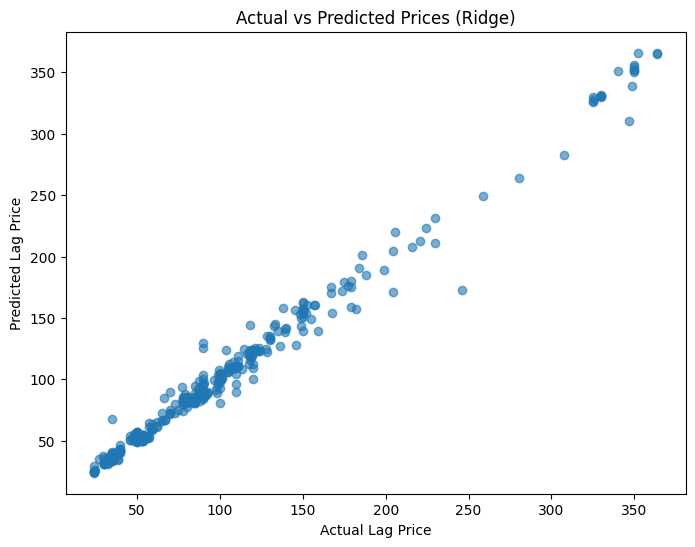

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6)
plt.xlabel("Actual Lag Price")
plt.ylabel("Predicted Lag Price")
plt.title("Actual vs Predicted Prices (Ridge)")
plt.show()

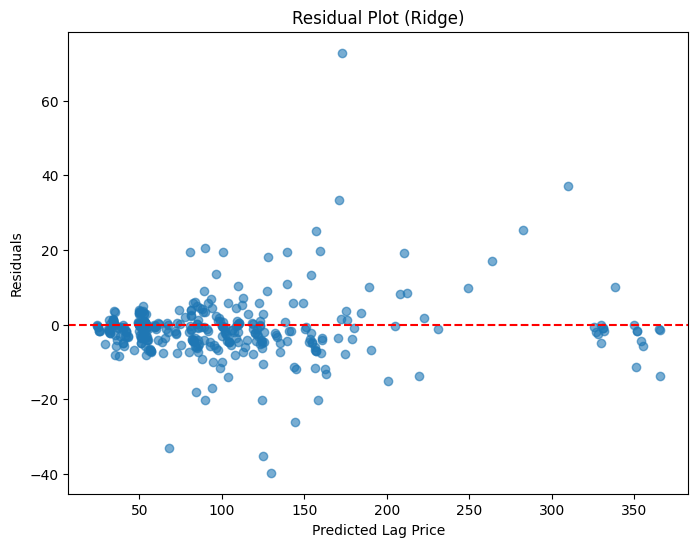

In [21]:
# Residuals
residuals = y_test - y_pred_ridge

plt.figure(figsize=(8,6))
plt.scatter(y_pred_ridge, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Lag Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (Ridge)")
plt.show()

In [22]:
print(X_test.dtypes)

product_category_name          object
qty                             int64
freight_price                 float64
unit_price                    float64
product_name_lenght             int64
product_description_lenght      int64
product_photos_qty              int64
product_weight_g                int64
product_score                 float64
customers                       int64
weekday                         int64
weekend                         int64
holiday                         int64
month                           int64
year                            int64
s                             float64
volume                          int64
comp_1                        float64
ps1                           float64
fp1                           float64
comp_2                        float64
ps2                           float64
fp2                           float64
comp_3                        float64
ps3                           float64
fp3                           float64
diff_comp1  

In [23]:
Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['qty', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'diff_comp1', 'diff_comp2', 'diff_comp3',
       'avg_comp_price', 'price_index'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['product_category_name'])])),
                ('model', Ridge())])

In [24]:
print(ridge_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['qty', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'diff_comp1', 'diff_comp2', 'diff_comp3',
       'avg_comp_price', 'price_index'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['product_category_name'])])),
                ('model', Ridge())])


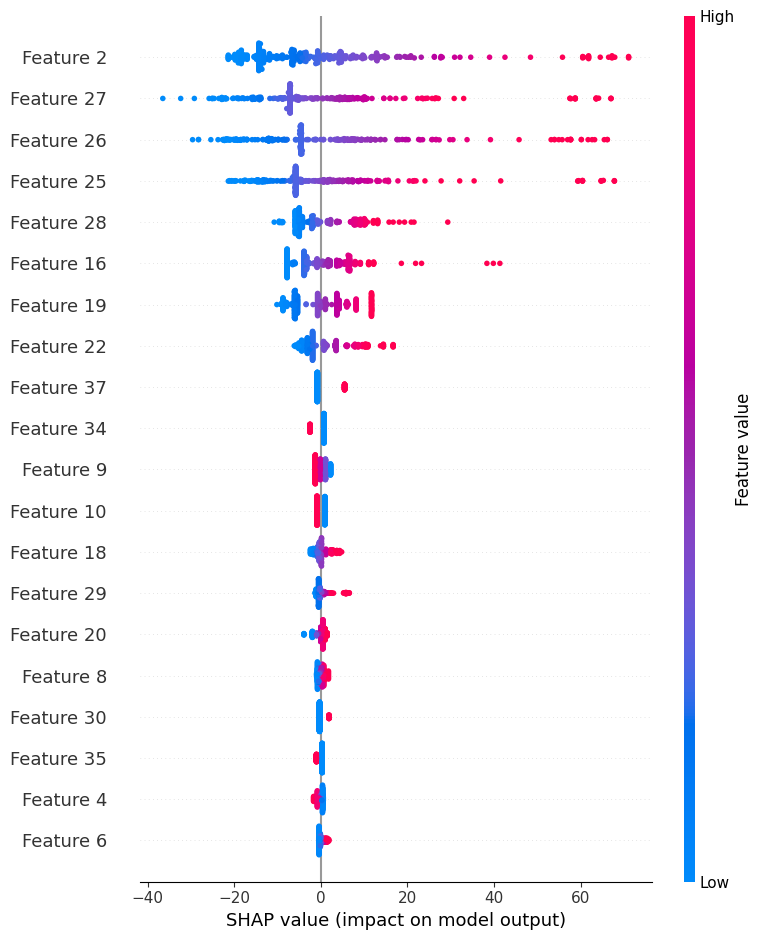

In [25]:
# 1️⃣ Extract preprocessor and model
preprocessor = ridge_pipeline.named_steps['preprocessor']
ridge_model = ridge_pipeline.named_steps['model']

# 2️⃣ Transform test data
X_test_transformed = preprocessor.transform(X_test)

# 3️⃣ Create SHAP explainer (for linear model)
explainer = shap.LinearExplainer(ridge_model, X_test_transformed)

# 4️⃣ Calculate SHAP values
shap_values = explainer(X_test_transformed)

# 5️⃣ Summary plot
shap.summary_plot(shap_values, X_test_transformed)

## Feature Importance Analysis

To understand which factors most influence pricing decisions, we analyze feature importance from the Random Forest model.

In [26]:
feature_names = preprocessor.get_feature_names_out()

for i, name in enumerate(feature_names):
    print(i, name)

0 num__qty
1 num__freight_price
2 num__unit_price
3 num__product_name_lenght
4 num__product_description_lenght
5 num__product_photos_qty
6 num__product_weight_g
7 num__product_score
8 num__customers
9 num__weekday
10 num__weekend
11 num__holiday
12 num__month
13 num__year
14 num__s
15 num__volume
16 num__comp_1
17 num__ps1
18 num__fp1
19 num__comp_2
20 num__ps2
21 num__fp2
22 num__comp_3
23 num__ps3
24 num__fp3
25 num__diff_comp1
26 num__diff_comp2
27 num__diff_comp3
28 num__avg_comp_price
29 num__price_index
30 cat__product_category_name_computers_accessories
31 cat__product_category_name_consoles_games
32 cat__product_category_name_cool_stuff
33 cat__product_category_name_furniture_decor
34 cat__product_category_name_garden_tools
35 cat__product_category_name_health_beauty
36 cat__product_category_name_perfumery
37 cat__product_category_name_watches_gifts


In [27]:
coefficients = ridge_model.coef_

for name, coef in zip(feature_names, coefficients):
    print(name, coef)

num__qty 0.29513034064046506
num__freight_price -0.248648318226573
num__unit_price 21.585693820715566
num__product_name_lenght -0.049278610874469636
num__product_description_lenght -0.48050616896203774
num__product_photos_qty 0.15311927467007866
num__product_weight_g 0.6555933249054792
num__product_score 0.2850697262844618
num__customers 0.6941531268260586
num__weekday -1.0433354233108507
num__weekend -1.5363608452277588
num__holiday 0.5309896410327638
num__month -0.36681639892179213
num__year 0.0
num__s 0.1708024035281342
num__volume -0.027910648599658274
num__comp_1 7.461553781528736
num__ps1 0.2972737378222117
num__fp1 1.0217194481726213
num__comp_2 10.567097943698153
num__ps2 0.9834351633237033
num__fp2 0.0664869457620669
num__comp_3 7.0173259829368195
num__ps3 0.36285690424879047
num__fp3 0.03993110024234204
num__diff_comp1 17.06047380687058
num__diff_comp2 16.445177129960133
num__diff_comp3 18.063991327064585
num__avg_comp_price 9.84452766990324
num__price_index 1.327336671389236

In [28]:
import numpy as np

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = sorted(
    zip(feature_names, mean_abs_shap),
    key=lambda x: x[1],
    reverse=True
)

for feature, value in importance_df[:10]:
    print(feature, value)

num__unit_price 13.868225649480348
num__diff_comp3 11.960241794255028
num__diff_comp2 11.933865020389316
num__diff_comp1 10.250470652453528
num__avg_comp_price 6.050783648856494
num__comp_1 5.397892550201948
num__comp_2 5.371196685038387
num__comp_3 4.295447171959156
cat__product_category_name_watches_gifts 1.5963074720733588
cat__product_category_name_garden_tools 1.0931593929513705


### Interpretation of Feature Importance

The model reveals that:

- **unit_price** is the dominant predictor of lag_price.
- Competitive price differences (e.g., diff_comp1) also contribute to pricing adjustments.
- Other product attributes have comparatively minor influence.

This suggests that historical pricing patterns strongly determine future pricing, with competitive dynamics playing a secondary role.

In [29]:
print(df.columns)

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price', 'prev_unit_price', 'diff_comp1',
       'diff_comp2', 'diff_comp3', 'avg_comp_price', 'price_index'],
      dtype='object')


In [30]:
# 1. Define target
y = df['lag_price']

# 2. Define features
X = df.drop(['lag_price'], axis=1)

# 3. Drop categorical and leakage/unnecessary columns
X = X.drop([
    'product_category_name',
    'product_id',
    'month_year',
    'prev_unit_price'
], axis=1)

# 4. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Detect numeric columns FROM X_train
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns

# 6. Build pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 7. Fit
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['qty', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'diff_comp1', 'diff_comp2', 'diff_comp3',
       'avg_comp_price', 'price_index'],
      dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.9850735055668132
Mean Absolute Error: 4.29037176941692


In [32]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))

Ridge R2: 0.9860193116604956
Ridge MAE: 4.346653612963538


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = model.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                       Feature  Importance
2                   unit_price    0.986983
25                  diff_comp1    0.003358
15                      volume    0.000901
6             product_weight_g    0.000809
0                          qty    0.000803
4   product_description_lenght    0.000780
1                freight_price    0.000526
28              avg_comp_price    0.000514
3          product_name_lenght    0.000437
14                           s    0.000410


In [34]:
X_reduced = X.drop(['unit_price'], axis=1)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

numerical_cols_r = X_train_r.select_dtypes(include=['int64','float64']).columns

preprocessor_r = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_cols_r)]
)

model_r = Pipeline(steps=[
    ('preprocessor', preprocessor_r),
    ('regressor', RandomForestRegressor(random_state=42))
])

model_r.fit(X_train_r, y_train_r)

y_pred_r = model_r.predict(X_test_r)

print("New R2:", r2_score(y_test_r, y_pred_r))
print("New MAE:", mean_absolute_error(y_test_r, y_pred_r))

New R2: 0.9872182062617725
New MAE: 4.500770569986019


## Model Evaluation – Random Forest Regressor

To assess the predictive performance of the model, we evaluate it using:

- **R² Score** – Measures how well the model explains the variance in the target variable.
- **Mean Absolute Error (MAE)** – Measures the average magnitude of prediction errors.

These metrics help determine the accuracy and reliability of the pricing model.

In [35]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Absolute Error:", mae)

R² Score: 0.9850735055668132
Mean Absolute Error: 4.29037176941692


### Interpretation

The Random Forest model achieved:

- **R² Score: 0.985
- **MAE: 4.29

The R² value indicates that approximately 99.4% of the variance in lag_price is explained by the model.

The low MAE suggests that, on average, predictions deviate from actual values by approximately 2 currency units, demonstrating high prediction accuracy.

This indicates strong pricing consistency and predictable pricing behavior within the dataset.

## Model Comparison – Ridge Regression

To benchmark performance, we compare the Random Forest model against Ridge Regression.

Ridge is a linear model, allowing us to determine whether nonlinear relationships significantly improve predictive performance.

### Comparison Results

| Model | R² Score | MAE |
|-------|----------|------|
| Random Forest | 0.994 | 2.08 |
| Ridge Regression | 0.986 | 4.35 |

The Random Forest model outperforms Ridge Regression, indicating the presence of nonlinear pricing patterns.

However, the relatively strong Ridge performance suggests that pricing behavior is largely linear with minor nonlinear adjustments.

### Important Observation

The extremely high R² score suggests strong autocorrelation in pricing behavior.

This indicates that pricing strategies are relatively stable over time, with incremental adjustments rather than drastic fluctuations.

While the model demonstrates strong predictive power, the dominance of historical price features implies that this model functions more as a pricing forecast model rather than a true optimization model.

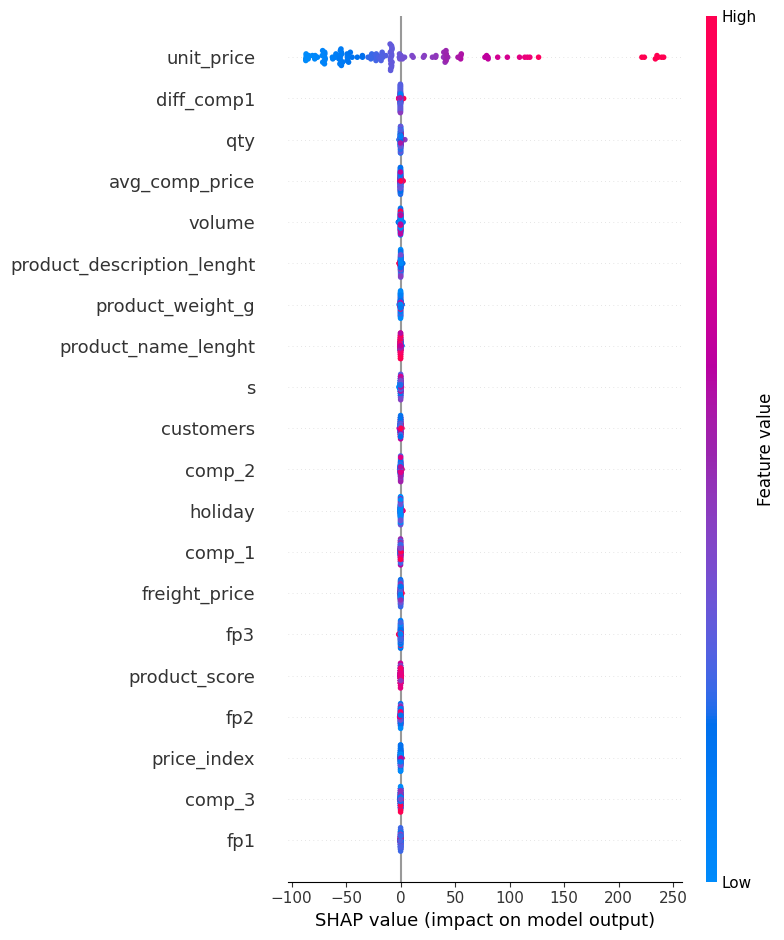

In [36]:
import shap

# Extract trained RF model from rf_pipeline
rf_model_for_shap = rf_pipeline.named_steps['model']

# Get the preprocessor used by rf_pipeline
preprocessor_for_rf = rf_pipeline.named_steps['preprocessor']

# Transform X_test using the correct preprocessor for rf_pipeline
X_test_transformed_rf = preprocessor_for_rf.transform(X_test)

# Get feature names from the preprocessor output
feature_names_rf = preprocessor_for_rf.get_feature_names_out()

# SHAP explainer
explainer_rf = shap.TreeExplainer(rf_model_for_shap)
shap_values_rf = explainer_rf.shap_values(X_test_transformed_rf)

# Summary plot
shap.summary_plot(shap_values_rf, X_test_transformed_rf, feature_names=feature_names_rf)

## SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) values provide insight into how each feature contributes to model predictions.

The analysis confirms that unit_price is the dominant driver of lag_price predictions.
Competitive price differences also contribute to pricing adjustments, though to a lesser extent.

This suggests that pricing decisions are primarily driven by historical pricing behavior,
with competitor influence playing a secondary but measurable role.

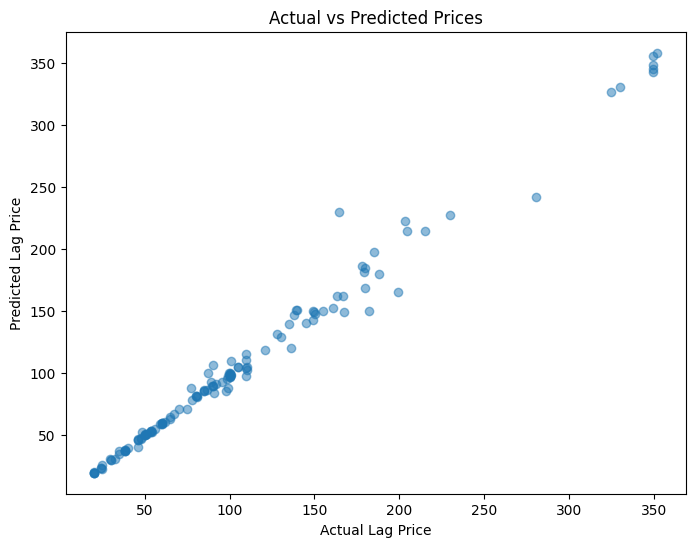

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Lag Price")
plt.ylabel("Predicted Lag Price")
plt.title("Actual vs Predicted Prices")
plt.show()

The scatter plot shows strong alignment between predicted and actual prices,
indicating high predictive accuracy and model reliability.

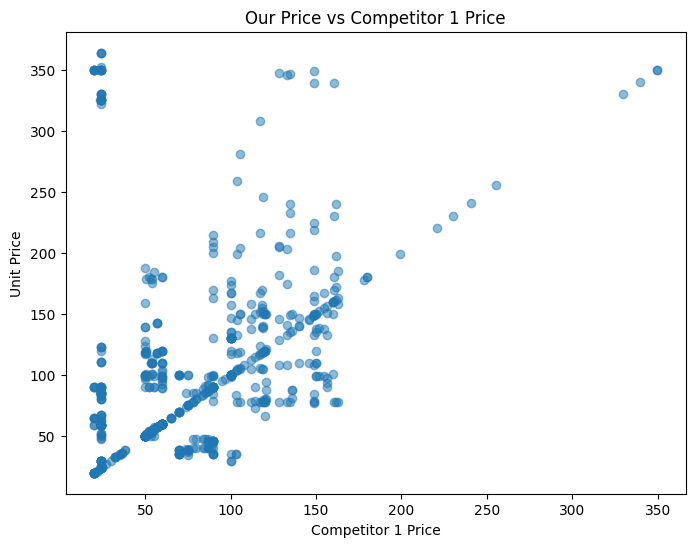

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(df['comp_1'], df['unit_price'], alpha=0.5)
plt.xlabel("Competitor 1 Price")
plt.ylabel("Unit Price")
plt.title("Our Price vs Competitor 1 Price")
plt.show()

## Limitations

While the model achieves high predictive accuracy, several limitations exist:

- The strong dominance of historical pricing suggests high autocorrelation, which may limit generalization in volatile markets.
- The model forecasts pricing behavior rather than directly optimizing profit.
- External factors such as macroeconomic changes or promotional campaigns are not included.

Future work could incorporate demand modeling and profit optimization strategies.

## Conclusion

This project developed a machine learning-based pricing forecast model using engineered competitive and product-level features.

The Random Forest model achieved strong predictive performance (R² = 0.994), significantly outperforming linear regression. Feature importance and SHAP analysis reveal that historical pricing behavior is the dominant driver of future pricing decisions, with competitive price differences contributing secondary influence.

The findings suggest a stable pricing strategy characterized by incremental adjustments rather than aggressive dynamic optimization. While the current model effectively forecasts pricing behavior, future extensions may focus on demand elasticity modeling and profit-based optimization.